In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (360, 16)

Columns:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

Missing Values:
Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

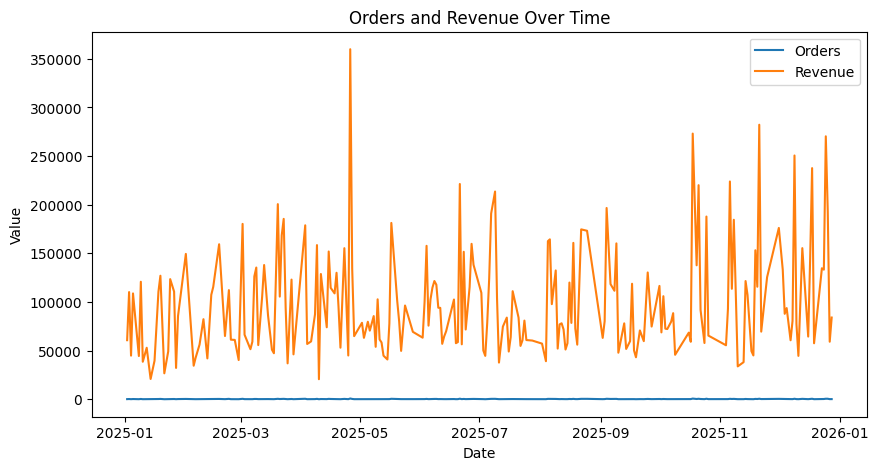

In [6]:
daily_data = df.groupby("Date")[["Orders", "Revenue"]].sum()

plt.figure(figsize=(10,5))

plt.plot(daily_data.index, daily_data["Orders"], label="Orders")
plt.plot(daily_data.index, daily_data["Revenue"], label="Revenue")

plt.title("Orders and Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.show()

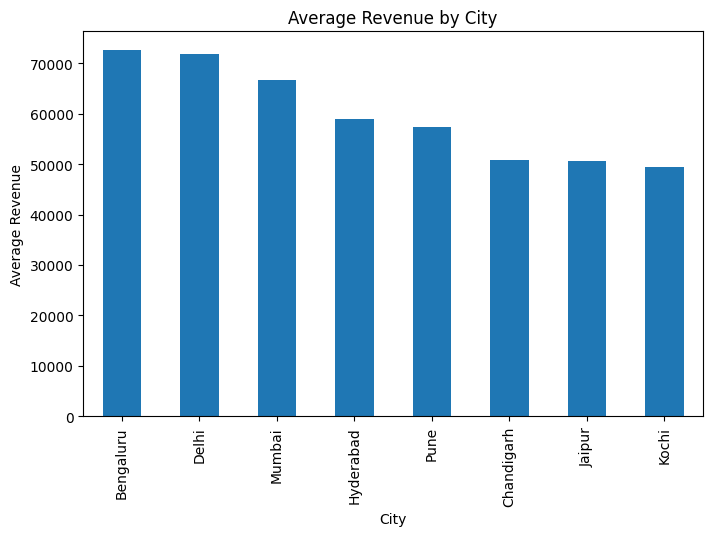

In [7]:
city_revenue = df.groupby("City")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

city_revenue.plot(kind="bar")

plt.title("Average Revenue by City")
plt.xlabel("City")
plt.ylabel("Average Revenue")

plt.show()

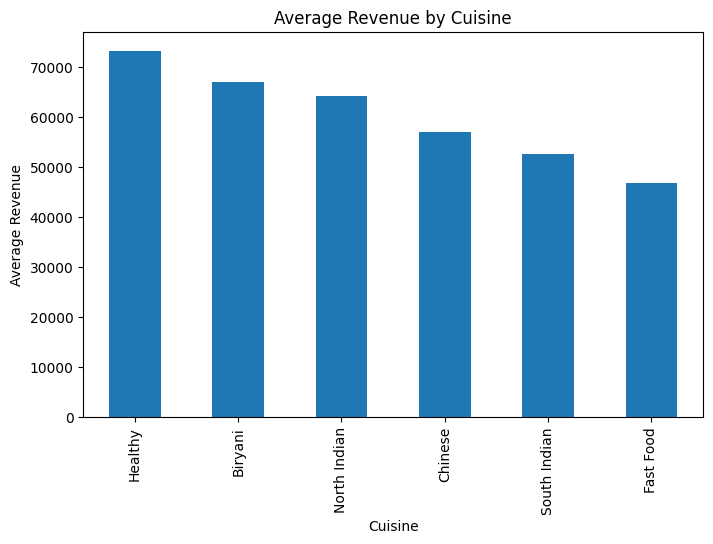

In [8]:
cuisine_revenue = df.groupby("Cuisine")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

cuisine_revenue.plot(kind="bar")

plt.title("Average Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Revenue")

plt.show()

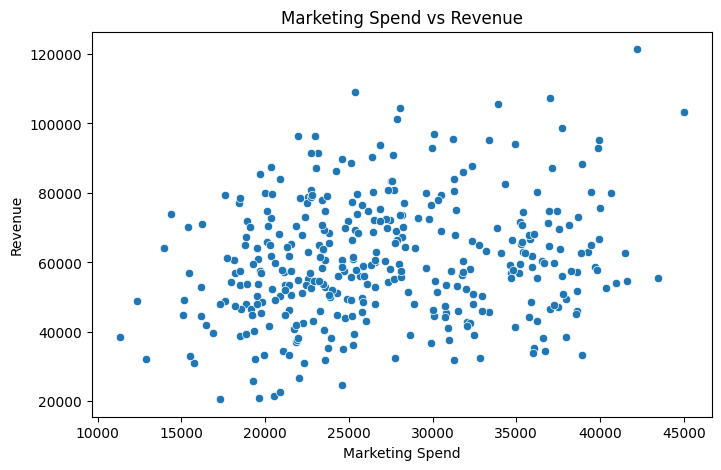

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue"
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")

plt.show()

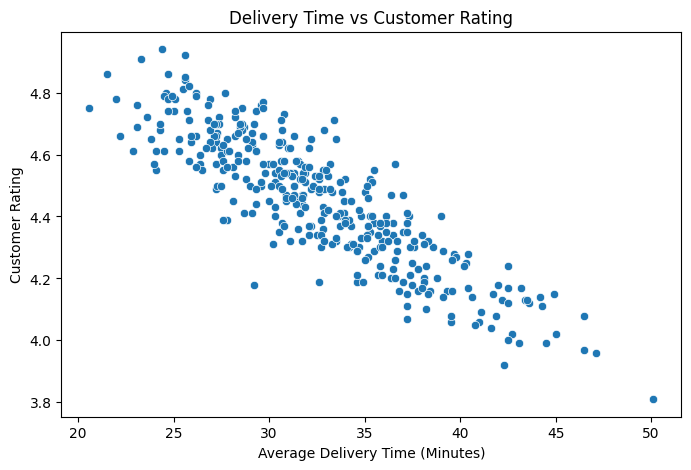

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating"
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")

plt.show()

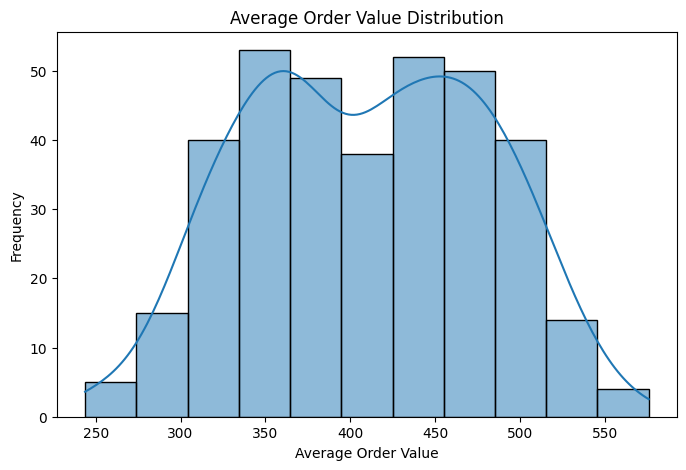

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Average_Order_Value",
    kde=True
)

plt.title("Average Order Value Distribution")
plt.xlabel("Average Order Value")
plt.ylabel("Frequency")

plt.show()

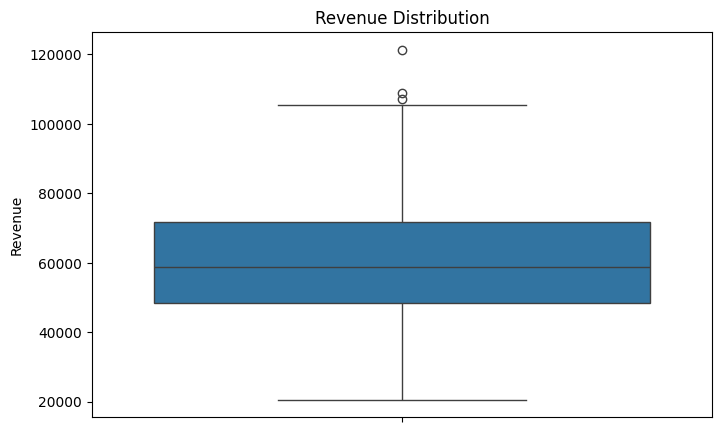

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Revenue"
)

plt.title("Revenue Distribution")
plt.ylabel("Revenue")

plt.show()

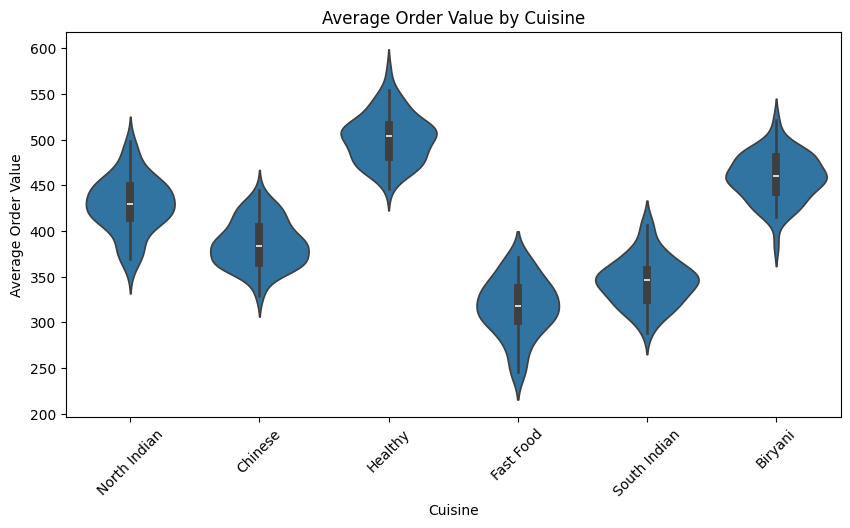

In [13]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x="Cuisine",
    y="Average_Order_Value"
)

plt.title("Average Order Value by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.show()

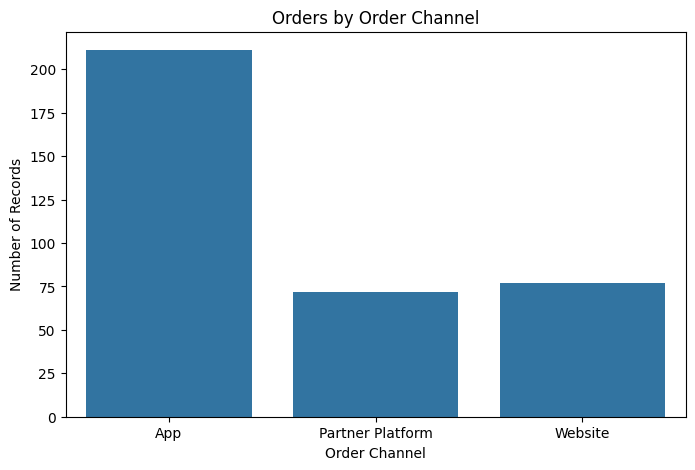

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Order_Channel"
)

plt.title("Orders by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Number of Records")

plt.show()

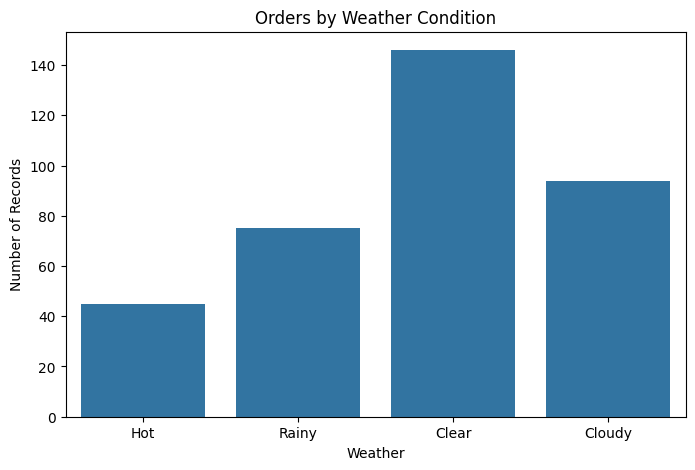

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.title("Orders by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Records")

plt.show()

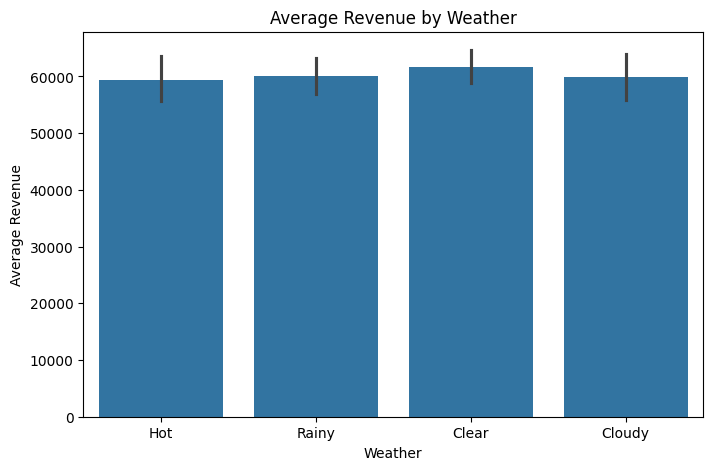

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Weather",
    y="Revenue"
)

plt.title("Average Revenue by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Revenue")

plt.show()

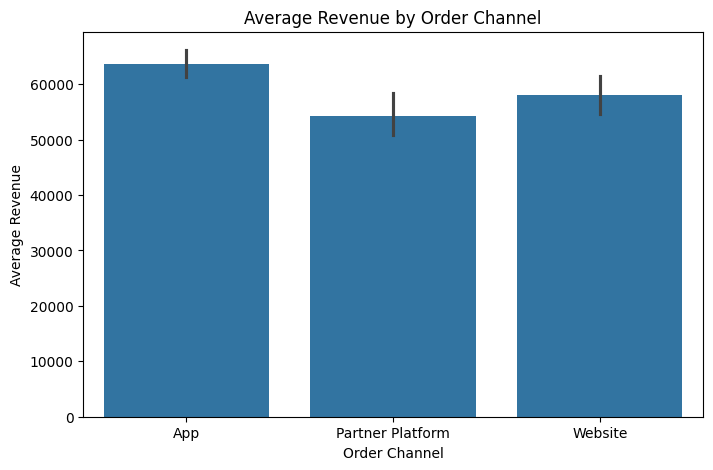

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Order_Channel",
    y="Revenue"
)

plt.title("Average Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Revenue")

plt.show()

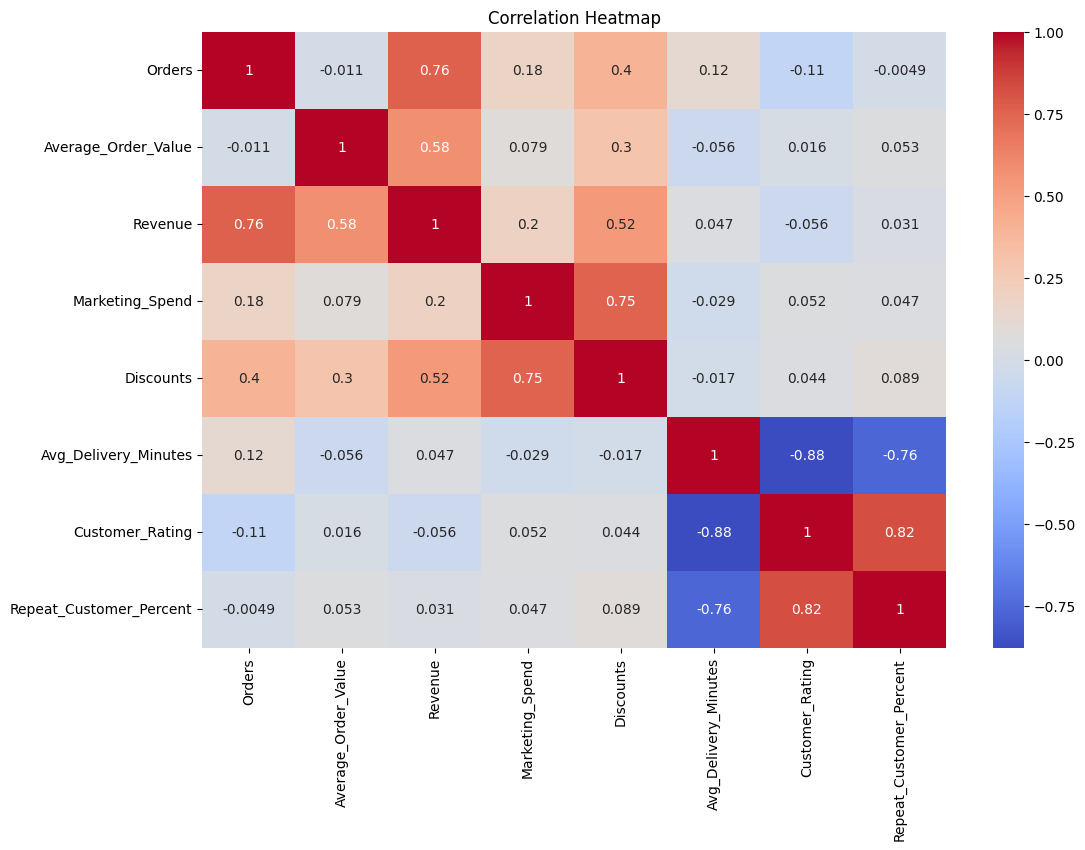

In [18]:
numeric_data = df.select_dtypes(include="number")

correlation = numeric_data.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
print("Marketing Spend vs Revenue:",
      df["Marketing_Spend"].corr(df["Revenue"]))

print("Delivery Time vs Customer Rating:",
      df["Avg_Delivery_Minutes"].corr(df["Customer_Rating"]))

print("Orders vs Revenue:",
      df["Orders"].corr(df["Revenue"]))

print("Average Order Value vs Revenue:",
      df["Average_Order_Value"].corr(df["Revenue"]))

Marketing Spend vs Revenue: 0.19812719039135182
Delivery Time vs Customer Rating: -0.8758810555011177
Orders vs Revenue: 0.7596171918471174
Average Order Value vs Revenue: 0.579618958269046


In [20]:
best_city = df.groupby("City")["Revenue"].mean().idxmax()

print("Highest Revenue City:", best_city)

Highest Revenue City: Bengaluru


In [21]:
best_cuisine = df.groupby("Cuisine")["Revenue"].mean().idxmax()

print("Highest Revenue Cuisine:", best_cuisine)

Highest Revenue Cuisine: Healthy


In [22]:
print("KEY FINDINGS")
print("------------")

print("1. Highest revenue city:",
      df.groupby("City")["Revenue"].mean().idxmax())

print("2. Highest revenue cuisine:",
      df.groupby("Cuisine")["Revenue"].mean().idxmax())

print("3. Highest revenue order channel:",
      df.groupby("Order_Channel")["Revenue"].mean().idxmax())

print("4. Highest revenue weather condition:",
      df.groupby("Weather")["Revenue"].mean().idxmax())

print("5. Orders vs Revenue correlation:",
      round(df["Orders"].corr(df["Revenue"]), 2))

print("6. Marketing Spend vs Revenue correlation:",
      round(df["Marketing_Spend"].corr(df["Revenue"]), 2))

print("7. Delivery Time vs Customer Rating correlation:",
      round(df["Avg_Delivery_Minutes"].corr(df["Customer_Rating"]), 2))

print("8. Average Order Value vs Revenue correlation:",
      round(df["Average_Order_Value"].corr(df["Revenue"]), 2))

KEY FINDINGS
------------
1. Highest revenue city: Bengaluru
2. Highest revenue cuisine: Healthy
3. Highest revenue order channel: App
4. Highest revenue weather condition: Clear
5. Orders vs Revenue correlation: 0.76
6. Marketing Spend vs Revenue correlation: 0.2
7. Delivery Time vs Customer Rating correlation: -0.88
8. Average Order Value vs Revenue correlation: 0.58
